Comenzamos importando pandas para poder obtener los datos de nuestro csv.

In [120]:
# Importaciones necesarias para correr el notebook correctamente
import pandas as pd;
import numpy as np;
import seaborn as sns;
import matplotlib.pyplot as plt;


pd.set_option('display.max_columns', None) #Modificamos el stting default de pandas para poder ver todas las columnas

datos_bancarios = pd.read_csv('../raw_data/bank-additional.csv', index_col = 0)
datos_bancarios.head(2)


,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097


Renombramos la columna de "_id" a "ID" para poder ejecutar el merge de manera directa on "ID".

In [121]:
datos_bancarios.rename(columns={'id_': 'ID'}, inplace=True)
datos_bancarios["ID"].head(3)

0    089b39d8-e4d0-461b-87d4-814d71e0e079
1    e9d37224-cb6f-4942-98d7-46672963d097
2    3f9f49b5-e410-4948-bf6e-f9244f04918b
Name: ID, dtype: object

Importamos los datos de nuestro xlsx.

In [122]:
datos_clientes_2012 = pd.read_excel(
    '../raw_data/customer-details.xlsx',
    sheet_name='2012',    
    index_col=0,          
    header=0,
    engine='openpyxl'
)
print('Clientes 2012')
datos_clientes_2012.head(2)


Clientes 2012


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097


In [123]:
datos_clientes_2013 = pd.read_excel(
    '../raw_data/customer-details.xlsx',
    sheet_name='2013',    
    index_col=0,          
    header=0,
    engine='openpyxl'
)
print('Clientes 2013')
datos_clientes_2013.head(2)

Clientes 2013


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479


In [124]:
datos_clientes_2014 = pd.read_excel(
    '../raw_data/customer-details.xlsx',
    sheet_name='2014',    
    index_col=0,          
    header=0,
    engine='openpyxl'
)
print('Clientes 2014')
datos_clientes_2014.head(2)

Clientes 2014


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,168812,1,1,2014-06-10,27,4d6c811c-0f24-4a73-b374-2ebd1f80d46e
1,108615,2,1,2014-04-05,24,eef0f24f-cbdb-4c67-b371-09d7bc59695e


Realizamos, ahora sí, el merge para contar con nuestros datos centralizados.

In [125]:

todos_clientes = pd.concat([ # Con este concat nos aseguramos de que los df se apilen en filas uniendo los datos en función de sus columnas
    datos_clientes_2012,
    datos_clientes_2013,
    datos_clientes_2014
], ignore_index=True)

todos_clientes = todos_clientes.drop_duplicates(subset='ID', keep='last') # Eliminamos los duplicados si existiesen

bank_data = datos_bancarios.merge(todos_clientes, how='left', on='ID') # merge para unificar los datos con nuestros datos bancarios

clientesDuplicados = bank_data.index.duplicated().sum()
bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04,29
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30,7


Para realizar el formateo de la columna 'Income' tendremos que obtener la serie, asegurarnos de que el type es correcto (float) y ayudarnos del .map para aplicar el formateo deseado.

En este caso el formateo consta de un separador de miles, dos decimales y con 'f' nos aseguramos de que sea legible como formato float.

In [126]:
bank_data['Income'] = bank_data['Income'].astype(float).round(2)
bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770.0,1,0,2012-04-04,29
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477.0,1,1,2012-12-30,7


Aprovechamos para deshacernos de las columnas innecesarias de 'latitude' y 'longitude'

In [127]:
bank_data.drop(["latitude","longitude"],axis = 1,inplace = True)

bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,089b39d8-e4d0-461b-87d4-814d71e0e079,161770.0,1,0,2012-04-04,29
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,e9d37224-cb6f-4942-98d7-46672963d097,85477.0,1,1,2012-12-30,7


Si nos fijamos en los datos podemos ver como tenemos dos columnas de fechas con formatos distintos, la más llamativa es la columna 'date' asi que vamos a asemejar ambas.                   
Para ello vamos a hacer lo siguiente:

Con el método isnull() controlamos los posibles null que nos encontremos.

In [128]:
meses = { # Creamos un diccionario con los nombres de los meses y su correspondiente valor numérico
        'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
        'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
        'septiembre': '09', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
}

def format_date(date):
    if pd.isnull(date):
        return None
    
    parts = date.split('-') #Separamos la fecha por los '-' para obtener las tres partes de la misma
    return parts[2] + '-' +  meses.get(parts[1]) + '-' + parts[0] # reformamos la fecha como a nosotros nos interesa YY/MM/DD

bank_data['date'] = pd.to_datetime(bank_data['date'].apply(format_date))
bank_data['Dt_Customer'] = pd.to_datetime(bank_data['Dt_Customer'])

bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2019-08-02,089b39d8-e4d0-461b-87d4-814d71e0e079,161770.0,1,0,2012-04-04,29
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2016-09-14,e9d37224-cb6f-4942-98d7-46672963d097,85477.0,1,1,2012-12-30,7


Ahora vamos a tratar la columna job, para asegurarnos de que los null se transformen en 'Unemployed'.                                               
Esta vez usaremos fillna para facilitar el proceso.

In [129]:
bank_data['job'] = bank_data['job'].fillna('Unemployed')

Vamos a comprobar ahora, de la misma manera, los clientes que no cuentan con estudios.

In [ ]:
bank_data['education'] = bank_data['education'].fillna('No studies')

AttributeError: 'Series' object has no attribute 'fillana'

Si nos fijamos en la columna de age, las edades están en float, vamos a solucionarlo.

In [ ]:
bank_data['age'].head(3)

0     NaN
1    57.0
2    37.0
Name: age, dtype: float64

In [ ]:
media_edad = np.mean(bank_data['age']).astype(int)        # Calculamos la media de edad y la convertimos a entero para que no nos de decimales
bank_data['age'] = bank_data['age'].fillna(0).astype(int) # Limpiamos los nulos de la edad rellenándolos con 0 y convirtiendo la columna a entero
bank_data['age'].head(3)

0     0
1    57
2    37
Name: age, dtype: int64

Sin embargo, no es lo más óptimo para el análisis dejar esos ceros ahí, por ello vamos a intercambiar esos ceros por la media de la edad, apra hacerle un poco de justicia al análisis

Teniendo en cuenta que la media de edad es de 39 años, vamos a realizar la sustitución


Text(0.5, 1.0, 'Distribución de edades')

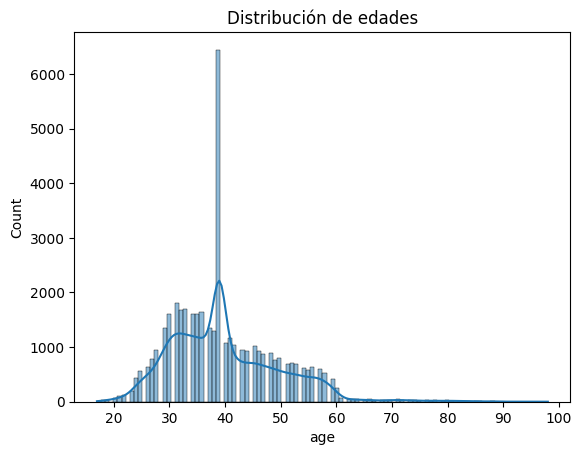

In [ ]:
print(f'Teniendo en cuenta que la media de edad es de {media_edad} años, vamos a realizar la sustitución')
    
bank_data['age'] = bank_data['age'].replace(0, media_edad)
sns.histplot(bank_data["age"], kde=True)
plt.title("Distribución de edades")


Limpiamos también los nulos de 'marital'.

In [ ]:
bank_data['marital'] = bank_data['marital'].fillna('NO ANSWER')
bank_data['marital'].unique()

array(['MARRIED', 'SINGLE', 'DIVORCED', 'NO ANSWER'], dtype=object)

Fijándonos un poco podemos darnos cuenta de que las columnas 'default', 'housing' y 'loan' son columnas booleanas, asi que vamos a formatearlas usando un mismo método y cambiando los valores por 'Yes' y 'No' para facilitar la legibilidad.

In [ ]:
# Vamos a usar el método fillNulls para limpiar las columnas y los pasamos a str para poder hacer la sustitución
cols = ['default', 'housing', 'loan']

# fillna para evitar NaN → "nan" o "0.0" al convertir a str
bank_data[cols] = bank_data[cols].fillna(0).astype(int).astype(str)

#Ahora vamos a sustituir los valores actuales por los deseados
bank_data[cols] = bank_data[cols].replace({'0': 'no', '1': 'yes'})
bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,0,housemaid,MARRIED,basic.4y,no,no,no,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2019-08-02,089b39d8-e4d0-461b-87d4-814d71e0e079,161770.0,1,0,2012-04-04,29
1,57,services,MARRIED,high.school,no,no,no,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,2016-09-14,e9d37224-cb6f-4942-98d7-46672963d097,85477.0,1,1,2012-12-30,7


Vamos a cambiar también el formato de nuestras columnas numéricas para ayudarnos con los cálculos en un futuro.

In [ ]:
cols_float = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

bank_data[cols_float] = bank_data[cols_float].astype(str).apply(lambda col: col.str.replace(',', '.')).astype(float)

Debido a la falta de comprensión que nos aportan los nombres de las columnas vamos a renombrar algunas de ellas.

In [ ]:
non_payment = bank_data['default']
bank_data.drop("default",axis = 1,inplace = True)
bank_data['non_payment_history'] = non_payment

subscribed = bank_data['y']
bank_data.drop("y",axis = 1,inplace = True)
bank_data['subscribed'] = subscribed

interaction_date = bank_data['date']
bank_data.drop("date",axis = 1,inplace = True)
bank_data['interaction_date'] = interaction_date

In [ ]:
bank_data.head(2)

,age,job,marital,education,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,non-payment-history,subcribed,interaction_date
0,39,housemaid,MARRIED,basic.4y,no,no,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,089b39d8-e4d0-461b-87d4-814d71e0e079,161770.0,1,0,2012-04-04,29,no,no,2019-08-02
1,57,services,MARRIED,high.school,no,no,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,e9d37224-cb6f-4942-98d7-46672963d097,85477.0,1,1,2012-12-30,7,no,no,2016-09-14


Filtrando nuestros datos por aquellos que cuentan sin educación, hemos llegado a la conclusión de que cuentan con la media de ingresos más superior.

In [ ]:
no_studies = bank_data['education'] == "No studies"
noEducationPeople = bank_data[no_studies]

noEducationPeopleMean = noEducationPeople['Income']
general_mean = bank_data['Income'].mean()

print(f'La media general es de :  {general_mean.round(2)}€')
print(f'La media de los clientes sin estudios es:  {noEducationPeopleMean.mean().round(2)}€')


La media general es de :  93241.2€
La media de los clientes sin estudios es:  93098.39€


Una vez tenemos nuestros datos comprensibles, empecemos a analizarlos.
Empezamos por agrupar los clientes por sus estudios y nos damos cuenta de que sorprendentemente aquellos que no tienen estudios cuentan con una media de ingresos superior al resto, y por otra parte, que aquellos con estudios básicos de seis años son los que menos ingresos tienen anualmente.

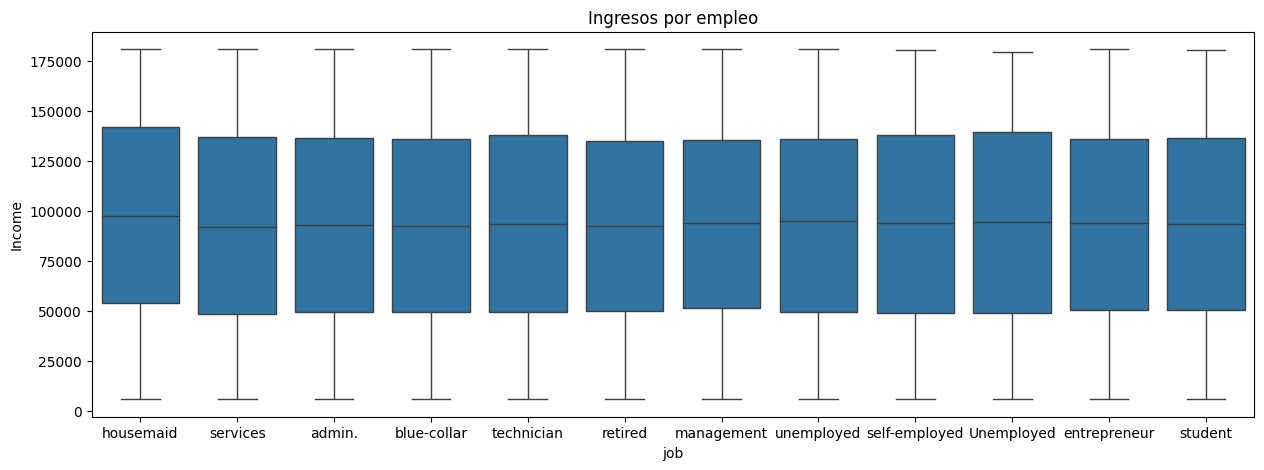

In [ ]:
bank_data['Income_mean'] = general_mean

plt.figure(figsize=(15, 5))
sns.boxplot(data=bank_data, x='job', y='Income')
plt.title('Ingresos por empleo')
plt.show()



Vamos a verlo más específicamente.

In [ ]:
# bank_data.groupby('marital')['Income'].head(2)
bank_data.groupby('education')['Income'].mean().reset_index().round(2)

,education,Income
0,No studies,93098.39
1,basic.4y,92337.68
2,basic.6y,92193.84
3,basic.9y,93563.36
4,high.school,94141.96
5,illiterate,80480.39
6,professional.course,93669.49
7,university.degree,92738.46


¿Cuáles son los tres trabajos mejor remunerados?

In [ ]:
bank_data.groupby('job')['Income'].mean().sort_values(ascending=False).round(2).head(3)

job
housemaid        97263.78
Unemployed       94065.30
self-employed    93804.71
Name: Income, dtype: float64

Agrupando ahora por situación amorosa llegamos a la conclusión de que los clientes que más han aguantado al teléfono han sido aquelllos que decidieron no responder a la misma. También comprobamos que el alcance de la campaña es de dos contactos de media esta última campaña para estos clientes.

In [ ]:
bank_data.groupby('marital').mean(numeric_only = True).astype(int)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,Income,Kidhome,Teenhome,NumWebVisitsMonth,Income_mean
marital,,,,,,,,,,,,,,
DIVORCED,44,251,2,968,0,0,93,-40,3,93684,1,0,16,93241
MARRIED,41,257,2,966,0,0,93,-40,3,93222,1,0,16,93241
NO ANSWER,40,312,3,940,0,0,93,-40,3,98710,0,0,17,93241
SINGLE,33,260,2,950,0,0,93,-40,3,93066,1,1,16,93241


Teniendo en cuenta el gráfico anterior, vamos a sacar nuestro primer KPI, el capital total del banco

In [ ]:
kpi_sumaIncome = bank_data['Income'].sum().round(2)
print(f'El capital total de la empresa es de {kpi_sumaIncome}€')

El capital total de la empresa es de 4009371603.0€


Nuestro siguiente KPI va a ser el total de clientes únicos que tenemos.

In [ ]:
# Como bien comprobamos anteriormente, no contamos con ningún cliente repetido.
print(f'Número de clientes repetidos: {clientesDuplicados}')

kpi_numClientes = bank_data.index.nunique()
print(f'El total de clientes que tiene el banco es de: {kpi_numClientes} clientes únicos')
# 

Número de clientes repetidos: 0
El total de clientes que tiene el banco es de: 43000 clientes únicos


Para nuestro tercer KPI vamos a calcular la correlación entre el índice de confianza del consumidor y la tasa de interes de referencia a tres meses consumidor, para obtener la correlación de 'salud económica' de nuestros clientes.

Cómo información es importante saber lo siguiente:

- 0.0 a -0.3: Economía estable

- 0.3 a -0.7: Tensión económica moderada

- 0.7 a -1.0: Crisis económica severa 

In [ ]:

kpi_correlacionSalud = bank_data[['cons.conf.idx', 'euribor3m']].corr().iloc[0,1].round(2)

if kpi_correlacionSalud <= 0 and kpi_correlacionSalud > -0.3:
    print(f"Economía estable: {kpi_correlacionSalud}")
elif kpi_correlacionSalud <= -0.3 and kpi_correlacionSalud > -0.7:
    print(f"Tensión económica moderada: {kpi_correlacionSalud}")
elif kpi_correlacionSalud <= -0.7:
    print(f"Crisis económica severa: {kpi_correlacionSalud}")


Por último vamos a sacar otro KPI para obtener la Volatilidad del Entorno MAcroeconómico (VEM) usando nuestra columna emp.var.rate.  
#                                               
Necesitaremos tener en cuenta:

# 
- CV < 20%: Mercado laboral muy estable
# 
- CV 20-50%: Volatilidad moderada
# 
- CV > 50%: Alta inestabilidad (crisis)

In [ ]:
volatilidad_empleo = bank_data['emp.var.rate'].std()
media_empleo = bank_data['emp.var.rate'].mean()
kpi_coefVariacion = ((volatilidad_empleo / abs(media_empleo)) * 100).round(2)

if kpi_coefVariacion <= 20:
    print(f"Mercado laboral muy estable: {kpi_coefVariacion}%")
elif kpi_coefVariacion >=20 and kpi_coefVariacion > 50:
    print(f"Volatilidad moderada: {kpi_coefVariacion}%")
elif kpi_coefVariacion >= 50:
    print(f"Alta inestabilidad (crisis): {kpi_coefVariacion}%")


Volatilidad moderada: 2040.63%


Tras este análisis ahora tenemos nuestros KPI´s:

# KPI CapitalTotal -> 1318152393.0€
# KPI NumClientes -> 14064 clientes únicos
# KPI CorrelacionSalud -> Economía estable: -0.09
# KPI CoefVariacion -> Volatilidad moderada: 61.51%

#
#
#
Visualicemos ahora las fechas en las que se incorporaron nuevos clientes

In [ ]:
df_contactosFecha = bank_data[['ID', 'Dt_Customer']].copy()
df_contactosFecha['Dt_Customer'].dt.year.unique()

array([2012, 2013, 2014], dtype=int32)

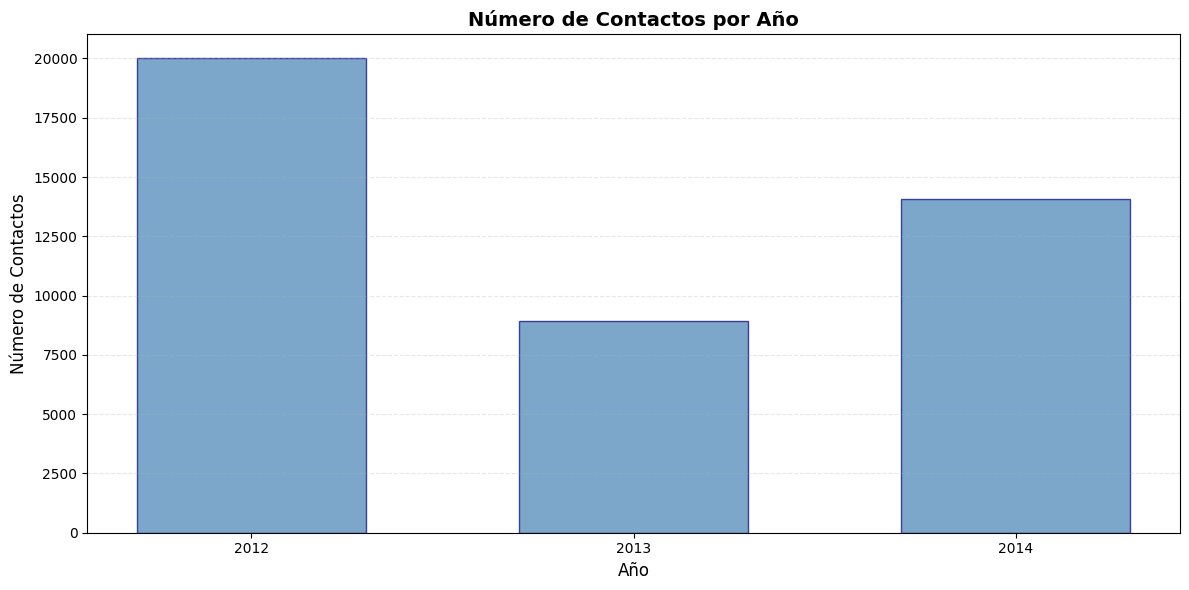

    año  contactos
0  2012      20018
1  2013       8918
2  2014      14064


In [ ]:
df_contactosFecha = bank_data[['ID', 'Dt_Customer']].copy()

df_contactosFecha['Dt_Customer'] = pd.to_datetime(df_contactosFecha['Dt_Customer']) # Convertir a datetime
df_contactosFecha['año'] = df_contactosFecha['Dt_Customer'].dt.year # Crear columna de año


# Agrupamos por año y contabilizamos el número de apariciones
contactos_año = df_contactosFecha.groupby('año').size().reset_index(name='contactos')

# Generamos el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(range(len(contactos_año)), 
        contactos_año['contactos'],
        color='steelblue',
        edgecolor='navy',
        alpha=0.7,
        width=0.6)

plt.xticks(range(len(contactos_año)), 
        contactos_año['año'], 
        rotation=0)  # Sin rotación porque son solo años

plt.title('Nuevos clientes por año', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Contactos', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

print(contactos_año)

El gráfico de barras muestra la evolución del crecimiento de la cartera de clientes del banco durante el período 2012-2014, determinando claramente cómo 2012 fue el año con mayor incremento de nuevos clientes y 2013 fue el año con menos inscripciones.